In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
df_trans = pd.read_csv('../data/raw/train_transaction.csv')
df_identity = pd.read_csv('../data/raw/train_identity.csv')


In [3]:
print("Transactions shape:", df_trans.shape)
print("Identity shape:", df_identity.shape)

Transactions shape: (590540, 394)
Identity shape: (144233, 41)


## Dataset Overview
- Transaction file: 590,540 rows and 394 columns
- Identity file: 144,233 rows and 41 columns
- Only 144,233 out of 590,540 transactions have identity data — that is 24.4%
- One row = one banking transaction
- We will merge both files on TransactionID using a left join

In [6]:
df_trans.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
fraud_counts = df_trans['isFraud'].value_counts()
fraud_pct = df_trans['isFraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print(fraud_pct)

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


## Target Variable — isFraud

- Legitimate transactions: 569,877 (96.5%)
- Fraudulent transactions: 20,663 (3.5%)
- This is severe class imbalance
- A model that predicts "not fraud" for every transaction would be 96.5% accurate
  but would catch zero frauds — making it completely useless
- This is why I will NOT use accuracy as my metric
- I will use Precision, Recall, and F1 score instead
- I will use SMOTE to handle the imbalance during training

/var/folders/fc/bv6xs4b94ybb9sp_wr4mj8f80000gn/T/ipykernel_56521/3637609660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df_trans, palette=['#2ecc71','#e74c3c'])


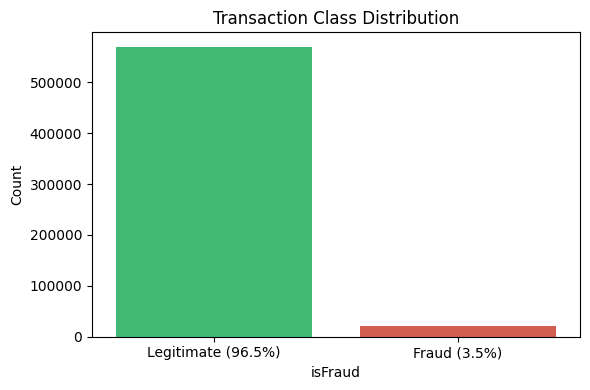

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df_trans, palette=['#2ecc71','#e74c3c'])
plt.title('Transaction Class Distribution')
plt.xticks([0,1], ['Legitimate (96.5%)', 'Fraud (3.5%)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../docs/class_distribution.png')
plt.show()

In [11]:
print(df_trans['TransactionAmt'].describe())

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


## Transaction Amount Overview

- Minimum transaction: $0.25
- Maximum transaction: $31,937
- Average transaction: $135
- Median transaction: $68.77
- The mean is nearly double the median — this tells us the distribution is 
  right-skewed, meaning a small number of very large transactions are pulling 
  the average up
- 75% of all transactions are under $125

In [12]:
df_trans.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [13]:
df_trans.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


## Transaction Amount Analysis

- Average legitimate transaction: $134.51
- Average fraud transaction: $149.24
- Fraud transactions have only 3% higher average amount than legitimate ones
- Median legitimate transaction: $68.50
- Median fraud transaction: $75.00
- The difference in medians is only $6.50 — very small
- High transaction amount does NOT reliably indicate fraud
- The maximum legitimate transaction ($31,937) is actually much higher than 
  the maximum fraud transaction ($5,191)
- The IEEE-CIS dataset has 3.5% fraud rate vs real-world 0.1% because Kaggle 
  competitions oversample fraud to make the problem more tractable
- In production the class imbalance would be even more severe

In [14]:
df_trans.isnull().sum().sort_values(ascending=False)

dist2            552913
D7               551623
D13              528588
D14              528353
D12              525823
                  ...  
C1                    0
C2                    0
C14                   0
isFraud               0
TransactionID         0
Length: 394, dtype: int64

In [15]:
552913 / 590540 * 100


93.62837403054831

In [18]:
551623 / 590540 * 100

89.04104717715988

In [20]:
528588 / 590540 * 100

89.50926270870728

In [22]:
528353 / 590540 * 100

89.46946862193924

In [21]:
525823 / 590540 * 100 

89.04104717715988

## Missing Values Analysis

- dist2: 93.63% missing
- D7: 89.04% missing
- D13: 89.51% missing
- D14: 89.47% missing
- D12: 89.04% missing

- When a column is 90%+ missing it means nearly all cells in that 
  column are empty and contain no useful information for the model

- Decision: drop all columns above 70-80% missing threshold during 
  cleaning phase — they add no value to model training

- Columns below 70% missing will be kept and filled with median 
  or mean depending on column type — this is called imputation

- Dropping vs imputing is a judgement call based on how much 
  data is actually present in each column

In [23]:
df_trans['hour'] = (df_trans['TransactionDT'] / 3600) % 24

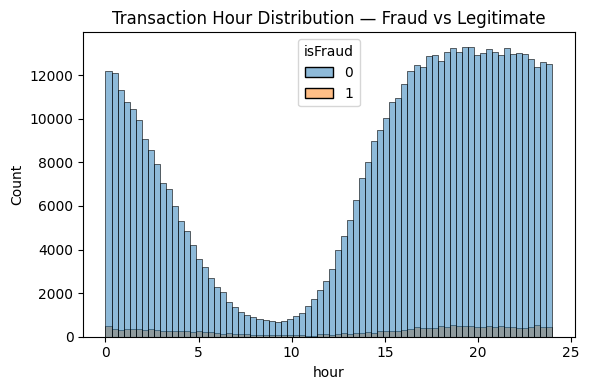

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(x='hour', data=df_trans,  hue='isFraud')
plt.title('Transaction Hour Distribution — Fraud vs Legitimate')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../docs/hour_distribution.png')
plt.show()

## Time Pattern Analysis

- Legitimate transactions peak between hours 17 and 24 (evening)
- Transaction volume drops significantly between hours 5 and 12 (early morning)
- Fraud transactions follow a similar overall pattern to legitimate ones
- However fraud does not drop as sharply during quiet hours
- There is a notable spike at midnight (hour 0) for both fraud and legitimate 
  transactions — this is common for automated fraudulent scripts
- During low volume hours the proportion of fraud among all transactions 
  may be higher even if absolute fraud numbers are lower
- Conclusion: hour of day will be a useful feature in my model because 
  fraud rate varies meaningfully across the day

In [25]:
df = pd.merge( df_trans,df_identity, on='TransactionID', how='left')

In [26]:
df.shape

(590540, 435)

## Merging Transaction and Identity Files

- Merged df_trans (590540 rows, 394 cols) with df_identity (144233 rows, 41 cols)
- Used a left join on TransactionID
- Result: 590540 rows and 435 columns
- All transactions are kept
- Only 144233 transactions have identity data — the rest have NaN for identity columns
- Left join was chosen so no transactions are lost during the merge

In [27]:
df.to_csv('../data/processed/merged_data.csv' , index=False)

In [ ]:
import os
os.path.getsize('../data/processed/merged_data.csv')